# Text generation

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 3.14.0
Keras backend: tensorflow


In [2]:
# Load and prepare text data
with open('./data/king_in_yellow.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 420749 characters
First 100 characters: THE KING IN YELLOW BY ROBERT W. CHAMBERS
Original publication date: 1895
THE KING IN YELLOW
IS DEDIC


In [3]:
# Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'king_in_yellow_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

vocab_sizes = [1000, 1500, 2000]
seq_lengths = [64, 96, 128]
embed_dims_list = [192, 224, 240]
num_heads_list = [4, 5, 6]
ff_dims = [384, 444, 512]
num_layers_list = [2, 2, 2]
num_epochs = 25

def train_spm(index):
    vocab_size = vocab_sizes[index]
    model_prefix = f'king_in_yellow_sp_{index + 1}'
    
    spm.SentencePieceTrainer.train(
        input=temp_file,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        character_coverage=1.0,  # Important for Finnish
        model_type='bpe',
        user_defined_symbols=['<PAD>', '<UNK>']
    )

    sp = spm.SentencePieceProcessor()
    sp.load(f"{model_prefix}.model")

    # Test tokenization
    test_text = "“I am content to serve him,” I replied."
    tokens = sp.encode_as_pieces(test_text)
    print(f"Tokenized example: {tokens}")
    print(f"Vocabulary size: {sp.get_piece_size()}")

    return sp

In [4]:
def create_sequences(index, sp):
    seq_length = seq_lengths[index]
    pieces = sp.encode_as_ids(text)
    print(f"Total tokens: {len(pieces)}")

    sequences = []
    for i in range(0, len(pieces) - seq_length):
        # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
        sequences.append(pieces[i:i+seq_length+1])

    sequences = np.array(sequences)
    inputs = sequences[:, :-1]  # All tokens except the last one
    targets = sequences[:, 1:]  # All tokens except the first one   

    print(f"Number of sequences: {len(sequences)}")
    print(f"Input shape: {inputs.shape}")
    print(f"Target shape: {targets.shape}")
    
    # Split into training and validation sets
    indices = np.arange(len(sequences))
    np.random.shuffle(indices)
    
    train_size = int(0.8 * len(sequences))
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    train_inputs, train_targets = inputs[train_indices], targets[train_indices]
    val_inputs, val_targets = inputs[val_indices], targets[val_indices]
    return train_inputs, train_targets, val_inputs, val_targets

In [5]:
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

text_models = []
model_values = []

# Create and compile 3 different models with various hyperparameters
for i in range(len(vocab_sizes)):
    print(f"Creating model {i+1}")
    model_values.append([])
    sp = train_spm(i)
    train_inputs, train_targets, val_inputs, val_targets = create_sequences(i, sp)
    model_values[i].append(train_inputs)
    model_values[i].append(train_targets)
    model_values[i].append(val_inputs)
    model_values[i].append(val_targets)

    embed_dim = embed_dims_list[i]
    num_heads = num_heads_list[i]
    ff_dim = ff_dims[i]
    num_layers = num_layers_list[i]
    seq_length = seq_lengths[i]

    # Create model
    inputs = keras.Input(shape=(seq_length,))
    embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)
    pos_encoding = get_positional_encoding(seq_length, embed_dim)
    x = embedding_layer + pos_encoding
    
    # Transformer blocks
    for _ in range(num_layers):
        # Multi-head attention with causal mask
        attention_output = keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=0.1
        )(x, x, use_causal_mask=True)
    
        # Add & Norm
        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
    
        # Feed-forward network
        ffn = keras.Sequential([
            keras.layers.Dense(ff_dim, activation="relu"),
            keras.layers.Dense(embed_dim),
            keras.layers.Dropout(0.1)
        ])
        ffn_output = ffn(x)
    
        # Add & Norm
        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    # Final output layer
    outputs = keras.layers.Dense(sp.get_piece_size())(x)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    
    model.summary()
    text_models.append(model)

Creating model 1
Tokenized example: ['▁“', 'I', '▁am', '▁cont', 'ent', '▁to', '▁ser', 've', '▁him', ',”', '▁I', '▁replied', '.']
Vocabulary size: 1000
Total tokens: 147568
Number of sequences: 147504
Input shape: (147504, 64)
Target shape: (147504, 64)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 192)   │    192,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 1000)  │    193,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 979,048 (3.73 MB)

 Trainable params: 979,048 (3.73 MB)

...

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 128, 240)  │    480,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 128, 240)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 240)  │    231,360 │ add_10[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 128, 240)  │          0 │ add_10[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 240)  │        480 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 128, 240)  │    246,512 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 128, 240)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 240)  │        480 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 240)  │    231,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 128, 240)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 240)  │        480 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 128, 240)  │    246,512 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 128, 240)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 240)  │        480 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128, 2000) │    482,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,919,664 (7.32 MB)

 Trainable params: 1,919,664 (7.32 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
batch_size = 64

histories = []
for i in range(len(text_models)):
    model = text_models[i]
    train_inputs = model_values[i][0]
    train_targets = model_values[i][1]
    val_inputs = model_values[i][2]
    val_targets = model_values[i][3]
    
    history = model.fit(
        train_inputs, train_targets,
        validation_data=(val_inputs, val_targets),
        batch_size=batch_size,
        epochs=num_epochs,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
            keras.callbacks.ModelCheckpoint('kalevala_best_model.keras', save_best_only=True)
        ]
        )
    histories.append(history)


Epoch 1/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.0851 - loss: 5.5354 - val_accuracy: 0.1526 - val_loss: 4.5131 - learning_rate: 5.0000e-05
Epoch 2/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.1596 - loss: 4.3010 - val_accuracy: 0.1734 - val_loss: 4.0615 - learning_rate: 5.0000e-05
Epoch 3/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.1752 - loss: 4.0044 - val_accuracy: 0.1910 - val_loss: 3.8536 - learning_rate: 5.0000e-05
Epoch 4/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 85s 46ms/step - accuracy: 0.1905 - loss: 3.8364 - val_accuracy: 0.2088 - val_loss: 3.7041 - learning_rate: 5.0000e-05
Epoch 5/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 85s 46ms/step - accuracy: 0.2059 - loss: 3.7078 - val_accuracy: 0.2254 - val_loss: 3.5843 - learning_rate: 5.0000e-05
Epoch 6/25
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 85s 46ms/step - accuracy: 0.2206 - loss: 3.5974 - val_accuracy: 0.2417 - val_loss: 3.4707 - learning_rate: 5.0000e-05
Epoch 7/25
1844/1844 ━━━━━━━━━━━━━━━━━━━

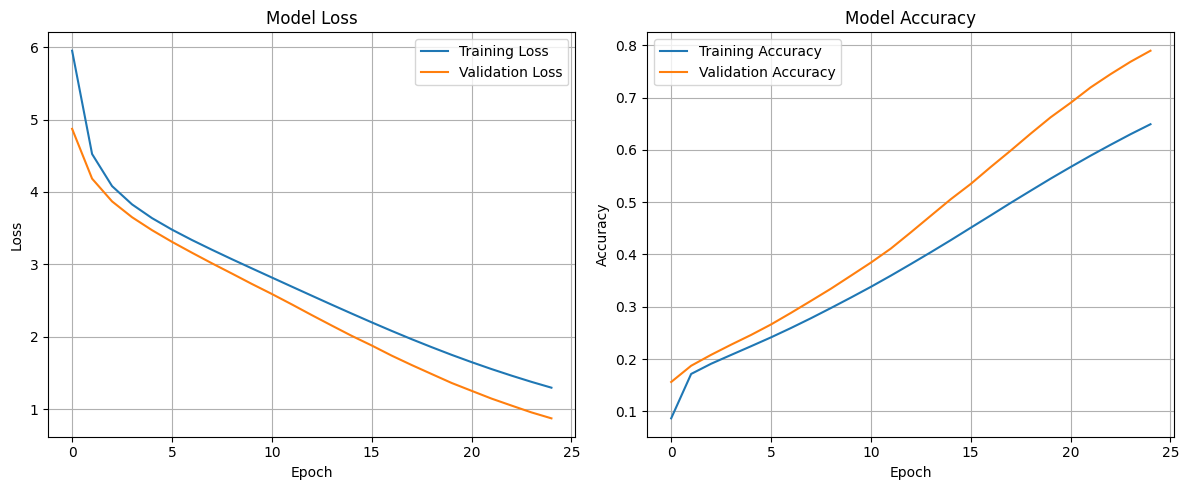

In [7]:
import matplotlib.pyplot as plt

for history in histories:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [8]:
model.save('king_in_yellow.keras')
print("Model saved as 'king_in_yellow.keras'")

Model saved as 'king_in_yellow.keras'


In [9]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [10]:
prompts = [
    "The King in Yellow",
    "I am content to serve",
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.2)
    print(generated)


Prompt: The King in Yellow
The King in Yellow might, I must not experimentommelet on me.” He held her close and dropping his voice, without her arms around in his arms and a helive. “I not know why, it is I have become so?” I asked of that she drew risure the cat. When she spoke she closed her small head and railing to me, aside her glance at me like the legs, trembled hope to I.” Mr. Wilde told her but

Prompt: I am content to serve
I am content to serveal the full of the opening War Office when I knelt and signed myself and myself every time. I started to myself. Although the r sprang upon my rose over his purring rang to the walk which it canop. I could not have wandered far down—they was hearing that I imagined he had slipped into a palette-knife at the cat, but in the cellar, out of the tallow distn
